In [21]:
import numpy as np
import h5py
import os 
from os import path
from matplotlib import pyplot as plt

In [22]:
output_files_path = "/home/itamarg/workspace/RICH/output/desmond_10kev"
path_to_initial_snap = path.join(output_files_path, f"snap_{0}.h5")

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("snap")])

num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())
    # print(h5_file["CMx"][:])

<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_15', 'Eg_16', 'Eg_17', 'Eg_18', 'Eg_19', 'Eg_2', 'Eg_20', 'Eg_21', 'Eg_22', 'Eg_23', 'Eg_24', 'Eg_25', 'Eg_26', 'Eg_27', 'Eg_28', 'Eg_29', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


In [23]:
speed_of_light = 2.99792458e10
stefan_boltzman = 5.670374e-5
radiation_constant = 4 * stefan_boltzman / speed_of_light
boltzmann_constant = 1.380649e-16

ev = 1.602176634e-12
kev = 1e3*ev

kev_to_kelvin = kev / boltzmann_constant

G=30
Emin = kev*1e-2
Emax = kev*1e2

energy_groups_boundary = np.geomspace(Emin, Emax, G+1)
energy_groups_boundary_kev = energy_groups_boundary / kev
energy_groups_width = np.diff(energy_groups_boundary, n=1)

In [24]:
Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"snap_{i}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

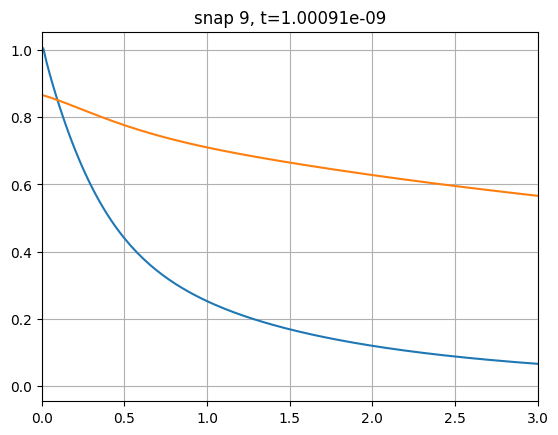

In [25]:
cell = 0
dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :]/kev_to_kelvin)
    plt.plot(CMx[i, :], Tr[i, :]/kev_to_kelvin)

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    plt.xlim(0, 3.)
    # plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()
    

<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_15', 'Eg_16', 'Eg_17', 'Eg_18', 'Eg_19', 'Eg_2', 'Eg_20', 'Eg_21', 'Eg_22', 'Eg_23', 'Eg_24', 'Eg_25', 'Eg_26', 'Eg_27', 'Eg_28', 'Eg_29', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


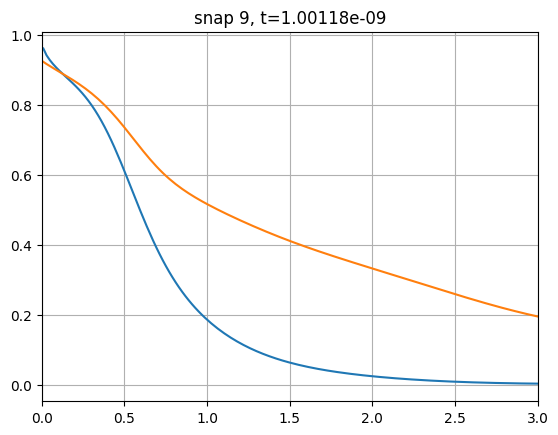

In [26]:
output_files_path = "/home/itamarg/workspace/RICH/output/desmond_100kev"
path_to_initial_snap = path.join(output_files_path, f"snap_{0}.h5")

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("snap")])

num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())
    # print(h5_file["CMx"][:])

Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"snap_{i}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :]/kev_to_kelvin)
    plt.plot(CMx[i, :], Tr[i, :]/kev_to_kelvin)

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    plt.xlim(0, 3.)
    # plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()

<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_15', 'Eg_16', 'Eg_17', 'Eg_18', 'Eg_19', 'Eg_2', 'Eg_20', 'Eg_21', 'Eg_22', 'Eg_23', 'Eg_24', 'Eg_25', 'Eg_26', 'Eg_27', 'Eg_28', 'Eg_29', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


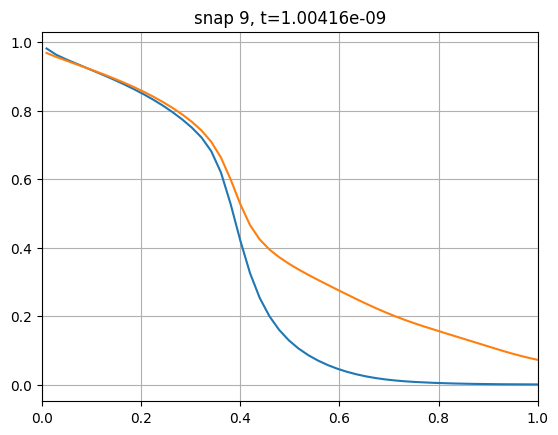

In [27]:
output_files_path = "/home/itamarg/workspace/RICH/output/desmond_1000kev"
path_to_initial_snap = path.join(output_files_path, f"snap_{0}.h5")

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("snap")])

num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())
    # print(h5_file["CMx"][:])

Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"snap_{i}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :]/kev_to_kelvin)
    plt.plot(CMx[i, :], Tr[i, :]/kev_to_kelvin)

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    plt.xlim(0, 1.)
    # plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()

<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_15', 'Eg_16', 'Eg_17', 'Eg_18', 'Eg_19', 'Eg_2', 'Eg_20', 'Eg_21', 'Eg_22', 'Eg_23', 'Eg_24', 'Eg_25', 'Eg_26', 'Eg_27', 'Eg_28', 'Eg_29', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


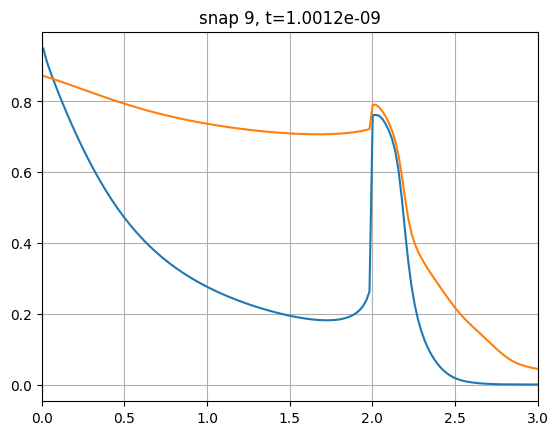

In [28]:
output_files_path = "/home/itamarg/workspace/RICH/output/desmond_step"
path_to_initial_snap = path.join(output_files_path, f"snap_{0}.h5")

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("snap")])

num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())
    # print(h5_file["CMx"][:])

Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"snap_{i}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        CMx[i, :] = np.array(h5_file["CMx"])
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :]/kev_to_kelvin)
    plt.plot(CMx[i, :], Tr[i, :]/kev_to_kelvin)

    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    plt.xlim(0, 3.)
    # plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()

<KeysViewHDF5 ['Box', 'CMx', 'CMy', 'CMz', 'Cycle', 'Density', 'Eg_0', 'Eg_1', 'Eg_10', 'Eg_11', 'Eg_12', 'Eg_13', 'Eg_14', 'Eg_15', 'Eg_16', 'Eg_17', 'Eg_18', 'Eg_19', 'Eg_2', 'Eg_20', 'Eg_21', 'Eg_22', 'Eg_23', 'Eg_24', 'Eg_25', 'Eg_26', 'Eg_27', 'Eg_28', 'Eg_29', 'Eg_3', 'Eg_4', 'Eg_5', 'Eg_6', 'Eg_7', 'Eg_8', 'Eg_9', 'Erad', 'ID', 'InternalEnergy', 'Pressure', 'Temperature', 'Time', 'Volume', 'Vx', 'Vy', 'Vz', 'X', 'Y', 'Z', 'stickers', 'tracers']>


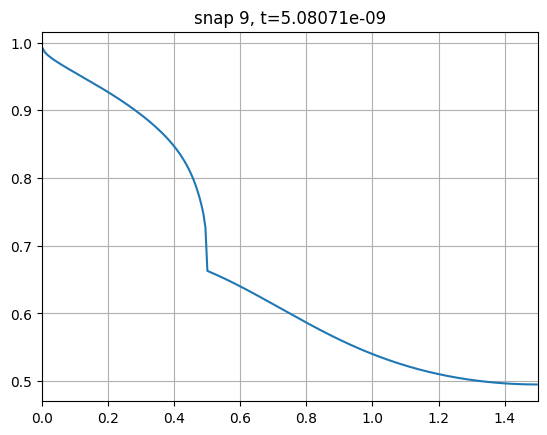

In [34]:
output_files_path = "/home/itamarg/workspace/RICH/output/desmond_step_2"
path_to_initial_snap = path.join(output_files_path, f"snap_{0}.h5")

num_of_snaps = len([file for file in os.listdir(output_files_path) if file.endswith(".h5") and file.startswith("snap")])

num_groups = 0
num_cells = 0

with h5py.File(path_to_initial_snap) as h5_file:
    num_cells = len(np.array(h5_file["Eg_0"]))
    num_groups = len([key for key in h5_file.keys() if "Eg" in key])
    print(h5_file.keys())
    # print(h5_file["CMx"][:])

Eg = np.ndarray(shape=(num_of_snaps, num_cells, num_groups))
Tm = np.ndarray(shape=(num_of_snaps, num_cells))
Tr = np.ndarray(shape=(num_of_snaps, num_cells))
Er = np.ndarray(shape=(num_of_snaps, num_cells))
CMx = np.ndarray(shape=(num_of_snaps, num_cells))
time = np.ndarray(shape=(num_of_snaps))

for i in range(num_of_snaps):
    path_to_snap = path.join(output_files_path, f"snap_{i}.h5")
    with h5py.File(path_to_snap) as h5_file:
        Tm[i, :] = np.array(h5_file["Temperature"])
        CMx[i, :] = np.array(h5_file["CMx"])
        Er[i, :] = np.array(h5_file["Erad"])
        Tr[i, :] = (Er[i, :] / radiation_constant)**0.25
        time[i] = h5_file["Time"][0]
        for g in range(num_groups):
            Eg[i, :, g] = np.array(h5_file[f"Eg_{g}"])*np.array(h5_file["Density"])

dir_figs = path.join(output_files_path, "material_temperature")
os.makedirs(dir_figs, exist_ok=True)

for i in range(num_of_snaps):
    plt.plot(CMx[i, :], Tm[i, :]/kev_to_kelvin)
    # plt.plot(CMx[i, :], Tr[i, :]/kev_to_kelvin)
    # for g in range(num_groups):
        # plt.plot(CMx[i, :], Eg[i, :]/kev_to_kelvin)
    plt.title(f"snap {i}, t={time[i]:g}")
    # plt.xscale("log")
    plt.xlim(0, 1.5)
    # plt.legend(loc="best")
    plt.grid()
    plt.savefig(path.join(dir_figs, f"snap_{i}.png"))
    if i == num_of_snaps - 1: plt.show()
    plt.close()